<a href="https://colab.research.google.com/github/ksyushik31/python-ai-Puhlenko-Ksenia/blob/main/notebooks/week3_visualization_crack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================
# 📥 ШАГ 1: ИМПОРТ БИБЛИОТЕК И ЗАГРУЗКА ДАННЫХ
# ==============================================

# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Настройка для отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ Библиотеки импортированы")
print("="*70)

# ==============================================
# 📁 ЗАГРУЗКА ВСЕХ ДАТАСЕТОВ ИЗ GITHUB
# ==============================================

# Ссылки на файлы (raw-формат)
urls = {
    'info': 'https://raw.githubusercontent.com/ksyushik31/python-ai-Puhlenko-Ksenia/main/data/parks_info.csv',
    'visitors': 'https://raw.githubusercontent.com/ksyushik31/python-ai-Puhlenko-Ksenia/main/data/park_visitors.csv',
    'social': 'https://raw.githubusercontent.com/ksyushik31/python-ai-Puhlenko-Ksenia/main/data/parks_social.csv',
    'types': 'https://raw.githubusercontent.com/ksyushik31/python-ai-Puhlenko-Ksenia/main/data/parks_types.csv'
}

# Загружаем данные
df_info = pd.read_csv(urls['info'])
df_visitors = pd.read_csv(urls['visitors'])
df_social = pd.read_csv(urls['social'])
df_types = pd.read_csv(urls['types'])

print("📊 Данные успешно загружены!")
print(f"• df_info: {df_info.shape} (строк, столбцов)")
print(f"• df_visitors: {df_visitors.shape}")
print(f"• df_social: {df_social.shape}")
print(f"• df_types: {df_types.shape}")
print("="*70)

# ==============================================
# 🔍 ЧАСТЬ 1: ДИАГНОСТИКА СТРУКТУРЫ ДАННЫХ
# ==============================================

# Словарь с датафреймами для удобной обработки
dfs = {
    'df_info': df_info,
    'df_visitors': df_visitors,
    'df_social': df_social,
    'df_types': df_types
}

# Функция для диагностики одного датафрейма
def diagnose_df(name, df):
    print(f"\n{'='*60}")
    print(f"=== {name} ===")
    print(f"{'='*60}")

    # 1. Список столбцов
    print(f"\n📋 Столбцы:")
    print(df.columns.tolist())

    # 2. Размер таблицы
    print(f"\n📏 Размер: {df.shape}")

    # 3. Первые 2 строки
    print(f"\n👀 Первые 2 строки:")
    display(df.head(2))

    # 4. Типы данных
    print(f"\n🔢 Типы данных:")
    print(df.dtypes)

    # 5. Проверка на пропуски
    print(f"\n⚠️ Пропуски (NaN):")
    missing = df.isna().sum()
    missing_pct = (missing / len(df) * 100).round(1)
    missing_df = pd.DataFrame({
        'Пропусков': missing,
        'Процент': missing_pct
    })
    display(missing_df[missing_df['Пропусков'] > 0])

# Запускаем диагностику для каждого датафрейма
for name, df in dfs.items():
    diagnose_df(name, df)
    print(f"\n{'─'*60}")

print("\n✅ Диагностика завершена!")

✅ Библиотеки импортированы
📊 Данные успешно загружены!
• df_info: (4878, 8) (строк, столбцов)
• df_visitors: (645, 4)
• df_social: (183, 4)
• df_types: (1426, 4)

=== df_info ===

📋 Столбцы:
['park', 'parkLabel', 'countryLabel', 'continentLabel', 'areaKm2', 'inceptionYear', 'elevation', 'coord']

📏 Размер: (4878, 8)

👀 Первые 2 строки:


,park,parkLabel,countryLabel,continentLabel,areaKm2,inceptionYear,elevation,coord
0,http://www.wikidata.org/entity/Q211816,Pioneer Peaks National Park,Австралия,Австралия и Океания,18.801129,2004.0,142.0,Point(148.923888888 -20.983888888)
1,http://www.wikidata.org/entity/Q211816,Pioneer Peaks National Park,Австралия,Австралия и Океания,189.000000,2004.0,142.0,Point(148.923888888 -20.983888888)



🔢 Типы данных:
park               object
parkLabel          object
countryLabel       object
continentLabel     object
areaKm2           float64
inceptionYear     float64
elevation         float64
coord              object
dtype: object

⚠️ Пропуски (NaN):


,Пропусков,Процент
inceptionYear,141,2.9
elevation,2414,49.5
coord,25,0.5



────────────────────────────────────────────────────────────

=== df_visitors ===

📋 Столбцы:
['park', 'parkLabel', 'visitors', 'year']

📏 Размер: (645, 4)

👀 Первые 2 строки:


...


────────────────────────────────────────────────────────────

=== df_types ===

📋 Столбцы:
['park', 'parkLabel', 'instanceType', 'instanceTypeLabel']

📏 Размер: (1426, 4)

👀 Первые 2 строки:


,park,parkLabel,instanceType,instanceTypeLabel
0,http://www.wikidata.org/entity/Q488639,Taeanhaean National Park,http://www.wikidata.org/entity/Q179049,заповедник
1,http://www.wikidata.org/entity/Q488639,Taeanhaean National Park,http://www.wikidata.org/entity/Q473972,природоохранная зона



🔢 Типы данных:
park                 object
parkLabel            object
instanceType         object
instanceTypeLabel    object
dtype: object

⚠️ Пропуски (NaN):


,Пропусков,Процент



────────────────────────────────────────────────────────────

✅ Диагностика завершена!


In [ ]:
# ==============================================
# 🛠️ ЧАСТЬ 2: ПОДГОТОВКА ДАННЫХ (6 шагов)
# ==============================================

print("="*70)
print("🔧 ШАГ 2.1: ПЕРЕИМЕНОВАНИЕ СТОЛБЦОВ")
print("="*70)

# Создаем копии для безопасной работы
df_info_clean = df_info.copy()
df_visitors_clean = df_visitors.copy()
df_social_clean = df_social.copy()
df_types_clean = df_types.copy()

# --- df_info: переименование ---
print("\n📁 df_info:")
# 'park' → 'URL' (ключевой столбец)
if 'park' in df_info_clean.columns:
    df_info_clean = df_info_clean.rename(columns={'park': 'URL'})
    print("✅ 'park' → 'URL'")

# *Label → короткие имена
label_columns = {
    'parkLabel': 'park',
    'countryLabel': 'country',
    'continentLabel': 'continent'
}
for old, new in label_columns.items():
    if old in df_info_clean.columns:
        df_info_clean = df_info_clean.rename(columns={old: new})
        print(f"✅ '{old}' → '{new}'")

# --- df_visitors: переименование ---
print("\n📁 df_visitors:")
if 'park' in df_visitors_clean.columns:
    df_visitors_clean = df_visitors_clean.rename(columns={'park': 'URL'})
    print("✅ 'park' → 'URL'")
if 'parkLabel' in df_visitors_clean.columns:
    df_visitors_clean = df_visitors_clean.rename(columns={'parkLabel': 'park'})
    print("✅ 'parkLabel' → 'park'")

# --- df_social: переименование ---
print("\n📁 df_social:")
if 'park' in df_social_clean.columns:
    df_social_clean = df_social_clean.rename(columns={'park': 'URL'})
    print("✅ 'park' → 'URL'")
if 'parkLabel' in df_social_clean.columns:
    df_social_clean = df_social_clean.rename(columns={'parkLabel': 'park'})
    print("✅ 'parkLabel' → 'park'")

# --- df_types: переименование ---
print("\n📁 df_types:")
if 'park' in df_types_clean.columns:
    df_types_clean = df_types_clean.rename(columns={'park': 'URL'})
    print("✅ 'park' → 'URL'")
if 'parkLabel' in df_types_clean.columns:
    df_types_clean = df_types_clean.rename(columns={'parkLabel': 'park'})
    print("✅ 'parkLabel' → 'park'")
if 'instanceTypeLabel' in df_types_clean.columns:
    df_types_clean = df_types_clean.rename(columns={'instanceTypeLabel': 'type'})
    print("✅ 'instanceTypeLabel' → 'type'")

print("\n" + "="*70)
print("🔢 ШАГ 2.2: ПРИВЕДЕНИЕ ТИПОВ ДАННЫХ")
print("="*70)
print("⚠️ ВАЖНО: НЕ применяем fillna(0) к optional-полям!")

# Числовые столбцы для преобразования
numeric_columns_info = ['areaKm2', 'elevation', 'inceptionYear']
numeric_columns_visitors = ['visitors', 'year']
numeric_columns_social = ['followers', 'year']

# df_info
print("\n📁 df_info:")
for col in numeric_columns_info:
    if col in df_info_clean.columns:
        df_info_clean[col] = pd.to_numeric(df_info_clean[col], errors='coerce')
        print(f"✅ '{col}' → числовой тип (float)")

# df_visitors
print("\n📁 df_visitors:")
for col in numeric_columns_visitors:
    if col in df_visitors_clean.columns:
        df_visitors_clean[col] = pd.to_numeric(df_visitors_clean[col], errors='coerce')
        print(f"✅ '{col}' → числовой тип (float)")

# df_social
print("\n📁 df_social:")
for col in numeric_columns_social:
    if col in df_social_clean.columns:
        df_social_clean[col] = pd.to_numeric(df_social_clean[col], errors='coerce')
        print(f"✅ '{col}' → числовой тип (float)")

print("\n" + "="*70)
print("🔄 ШАГ 2.3: УДАЛЕНИЕ ДУБЛИКАТОВ (df_info)")
print("="*70)

rows_before = len(df_info_clean)
print(f"📊 Строк до удаления: {rows_before}")

# Сортируем по inceptionYear (от старых к новым) и удаляем дубликаты URL
if 'inceptionYear' in df_info_clean.columns:
    df_info_clean = df_info_clean.sort_values('inceptionYear', ascending=True)
    df_info_clean = df_info_clean.drop_duplicates(subset='URL', keep='first')
else:
    df_info_clean = df_info_clean.drop_duplicates(subset='URL', keep='first')

rows_after = len(df_info_clean)
rows_removed = rows_before - rows_after

print(f"📊 Строк после удаления: {rows_after}")
print(f"🗑️ Удалено дубликатов: {rows_removed}")
print(f"✅ Уникальных URL теперь: {df_info_clean['URL'].nunique()}")

print("\n" + "="*70)
print("📍 ШАГ 2.4: ПАРСИНГ КООРДИНАТ")
print("="*70)

import re

def parse_coord(coord_str):
    """
    Парсит строку 'Point(lon lat)' в долготу и широту
    Пример: 'Point(148.92 -20.98)' → (148.92, -20.98)
    """
    if pd.isna(coord_str) or not isinstance(coord_str, str):
        return pd.Series([None, None])

    # Регулярное выражение для извлечения двух чисел
    match = re.search(r'Point\(([-\d.]+)\s+([-\d.]+)\)', coord_str)

    if match:
        lon = float(match.group(1))
        lat = float(match.group(2))
        return pd.Series([lon, lat])

    return pd.Series([None, None])

# Применяем парсинг
if 'coord' in df_info_clean.columns:
    print("⏳ Извлечение координат...")
    df_info_clean[['longitude', 'latitude']] = df_info_clean['coord'].apply(parse_coord)

    # Статистика
    coord_count = df_info_clean['latitude'].notna().sum()
    total = len(df_info_clean)
    print(f"✅ Координаты извлечены для {coord_count} из {total} парков ({coord_count/total*100:.1f}%)")

    # Проверка аномалий
    lat_invalid = ((df_info_clean['latitude'] < -90) | (df_info_clean['latitude'] > 90)).sum()
    lon_invalid = ((df_info_clean['longitude'] < -180) | (df_info_clean['longitude'] > 180)).sum()
    print(f"✅ Аномалий не найдено: широта={lat_invalid}, долгота={lon_invalid}")

print("\n" + "="*70)
print("🔗 ШАГ 2.5: ОБЪЕДИНЕНИЕ ТАБЛИЦ")
print("="*70)

# 1. Находим год с максимальным покрытием для visitors
print("\n📈 Анализ покрытия по годам (visitors):")
year_coverage = df_visitors_clean.groupby('year')['URL'].nunique().sort_values(ascending=False)
best_year_visitors = year_coverage.index[0]
best_year_count = year_coverage.iloc[0]
print(f"🏆 Лучший год: {int(best_year_visitors)} (данные для {best_year_count} парков)")

# 2. Находим год с максимальным покрытием для social
print("\n📱 Анализ покрытия по годам (social):")
year_coverage_social = df_social_clean.groupby('year')['URL'].nunique().sort_values(ascending=False)
best_year_social = year_coverage_social.index[0]
best_year_social_count = year_coverage_social.iloc[0]
print(f"🏆 Лучший год: {int(best_year_social)} (данные для {best_year_social_count} парков)")

# 3. Создаем срезы за лучшие годы
visitors_best = df_visitors_clean[df_visitors_clean['year'] == best_year_visitors][['URL', 'visitors']].copy()
social_best = df_social_clean[df_social_clean['year'] == best_year_social][['URL', 'followers']].copy()

# 4. Объединяем всё в один датафрейм
df_merged = df_info_clean.copy()

# Добавляем посетителей
df_merged = pd.merge(df_merged, visitors_best, on='URL', how='left')
print(f"\n✅ После добавления visitors: {df_merged['visitors'].notna().sum()} парков с данными")

# Добавляем подписчиков
df_merged = pd.merge(df_merged, social_best, on='URL', how='left')
print(f"✅ После добавления followers: {df_merged['followers'].notna().sum()} парков с данными")

# 5. Считаем итоговое пересечение
complete_cases = df_merged[['visitors', 'followers']].notna().all(axis=1).sum()
print(f"\n🎯 Итоговое пересечение (есть и visitors, и followers): {complete_cases} парков")

print("\n" + "="*70)
print("📊 ШАГ 2.6: ДОБАВЛЕНИЕ ЛОГАРИФМИЧЕСКИХ СТОЛБЦОВ")
print("="*70)

# Добавляем log_visitors (псевдо-счет, чтобы избежать -inf)
df_merged['log_visitors'] = np.log1p(df_merged['visitors'].fillna(0))
df_merged['log_followers'] = np.log1p(df_merged['followers'].fillna(0))

# Проверка результатов
print("✅ Логарифмические столбцы созданы:")
print(f"   • log_visitors: от {df_merged['log_visitors'].min():.2f} до {df_merged['log_visitors'].max():.2f}")
print(f"   • log_followers: от {df_merged['log_followers'].min():.2f} до {df_merged['log_followers'].max():.2f}")

print("\n" + "="*70)
print("📋 ФИНАЛЬНАЯ ПРОВЕРКА ДАННЫХ")
print("="*70)

print(f"\n📊 df_info_clean: {df_info_clean.shape}")
print(f"📊 df_merged (основной для визуализаций): {df_merged.shape}")

print("\n🔍 Первые 3 строки финального датафрейма:")
display(df_merged[['park', 'country', 'areaKm2', 'visitors', 'followers', 'longitude', 'latitude']].head(3))

print("\n📊 Статистика пропусков в финальном датафрейме:")
missing_final = df_merged[['visitors', 'followers', 'elevation', 'inceptionYear']].isna().sum()
display(pd.DataFrame({'Пропусков': missing_final}))

print("\n" + "="*70)
print("✅ ПОДГОТОВКА ДАННЫХ ЗАВЕРШЕНА!")
print("="*70)
print("\n💡 Дальнейшие шаги (по вашему запросу):")
print("   • Часть 3: Анализ выбросов и распределений")
print("   • Часть 4: Временные ряды")
print("   • Часть 5: Корреляционный анализ")
print("   • Часть 6: Интерактивные визуализации")

🔧 ШАГ 2.1: ПЕРЕИМЕНОВАНИЕ СТОЛБЦОВ

📁 df_info:
✅ 'park' → 'URL'
✅ 'parkLabel' → 'park'
✅ 'countryLabel' → 'country'
✅ 'continentLabel' → 'continent'

📁 df_visitors:
✅ 'park' → 'URL'
✅ 'parkLabel' → 'park'

📁 df_social:
✅ 'park' → 'URL'
✅ 'parkLabel' → 'park'

📁 df_types:
✅ 'park' → 'URL'
✅ 'parkLabel' → 'park'
✅ 'instanceTypeLabel' → 'type'

🔢 ШАГ 2.2: ПРИВЕДЕНИЕ ТИПОВ ДАННЫХ
⚠️ ВАЖНО: НЕ применяем fillna(0) к optional-полям!

📁 df_info:
✅ 'areaKm2' → числовой тип (float)
✅ 'elevation' → числовой тип (float)
✅ 'inceptionYear' → числовой тип (float)

📁 df_visitors:
✅ 'visitors' → числовой тип (float)
✅ 'year' → числовой тип (float)

📁 df_social:
✅ 'followers' → числовой тип (float)
✅ 'year' → числовой тип (float)

🔄 ШАГ 2.3: УДАЛЕНИЕ ДУБЛИКАТОВ (df_info)
📊 Строк до удаления: 4878
📊 Строк после удаления: 1954
🗑️ Удалено дубликатов: 2924
✅ Уникальных URL теперь: 1954

📍 ШАГ 2.4: ПАРСИНГ КООРДИНАТ
⏳ Извлечение координат...
✅ Координаты извлечены для 1930 из 1954 парков (98.8%)
✅ Аномалий н

,park,country,areaKm2,visitors,followers,longitude,latitude
0,Нитмилук,Австралия,1131.729766,NaN,NaN,132.423000,-14.312200
1,Previously called Mafou Classified Forest Nati...,Гвинея,524.000000,NaN,NaN,NaN,NaN
2,Форт Иисус,Кения,0.310000,NaN,NaN,39.682056,-4.071167



📊 Статистика пропусков в финальном датафрейме:


,Пропусков
visitors,1901
followers,1902
elevation,1323
inceptionYear,126



✅ ПОДГОТОВКА ДАННЫХ ЗАВЕРШЕНА!

💡 Дальнейшие шаги (по вашему запросу):
   • Часть 3: Анализ выбросов и распределений
   • Часть 4: Временные ряды
   • Часть 5: Корреляционный анализ
   • Часть 6: Интерактивные визуализации


In [ ]:
# ==============================================
# 📊 ЧАСТЬ 3: РЕГРЕССИОННЫЙ АНАЛИЗ (ТОЛЬКО РАСЧЁТЫ)
# ==============================================

import numpy as np
import pandas as pd
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("📈 ШАГ 3.1: ЛИНЕЙНАЯ РЕГРЕССИЯ (log_followers ~ log_visitors)")
print("="*70)

# Убеждаемся, что df_regression существует
if 'df_regression' not in locals():
    df_regression = df_merged[df_merged[['visitors', 'followers']].notna().all(axis=1)].copy()
    print("✅ df_regression создан заново")

# 1. Строим регрессию
slope, intercept, r_value, p_value, stderr = stats.linregress(
    df_regression['log_visitors'],
    df_regression['log_followers']
)

# 2. Выводим статистику (только числа, без графиков)
print("\n📊 РЕЗУЛЬТАТЫ РЕГРЕССИИ")
print("-"*50)
print(f"• Slope (коэффициент): {slope:.4f}")
print(f"• Intercept (свободный член): {intercept:.4f}")
print(f"• R-squared (коэфф. детерминации): {r_value**2:.4f}")
print(f"• R (корреляция Пирсона): {r_value:.4f}")
print(f"• P-value: {p_value:.6f}")
print(f"• Std Error: {stderr:.4f}")
print(f"• Выборка: {len(df_regression)} парков")

# 3. Интерпретация
print("\n🔍 ИНТЕРПРЕТАЦИЯ:")
print("-"*50)
if r_value**2 > 0.7:
    print("✅ R² > 0.7 → Сильная линейная связь")
elif r_value**2 > 0.3:
    print("⚠️ R² между 0.3 и 0.7 → Умеренная связь")
else:
    print("❌ R² < 0.3 → Слабая связь")

if p_value < 0.05:
    print("✅ P-value < 0.05 → Связь статистически значима")
else:
    print("❌ P-value ≥ 0.05 → Связь статистически не значима")

print("\n" + "="*70)
print("📊 ШАГ 3.2: РАСЧЁТ PREDICTED И RESIDUAL")
print("="*70)

# 1. Добавляем столбцы
df_regression['predicted_log_followers'] = slope * df_regression['log_visitors'] + intercept
df_regression['residual'] = df_regression['log_followers'] - df_regression['predicted_log_followers']

# 2. Статистика residual
print("\n📊 СТАТИСТИКА RESIDUAL:")
print("-"*50)
print(f"• Среднее: {df_regression['residual'].mean():.4f}")
print(f"• Медиана: {df_regression['residual'].median():.4f}")
print(f"• Std: {df_regression['residual'].std():.4f}")
print(f"• Мин: {df_regression['residual'].min():.4f}")
print(f"• Макс: {df_regression['residual'].max():.4f}")

# 3. Квартили
print("\n📊 КВАРТИЛИ RESIDUAL:")
print("-"*50)
quartiles = df_regression['residual'].quantile([0.25, 0.5, 0.75])
print(f"• Q1 (25%): {quartiles[0.25]:.4f}")
print(f"• Q2 (50%): {quartiles[0.5]:.4f}")
print(f"• Q3 (75%): {quartiles[0.75]:.4f}")

print("\n" + "="*70)
print("🌟 ШАГ 3.3: ТОП АНОМАЛИЙ")
print("="*70)

# Топ-5 "цифровых звёзд" (положительные residuals)
print("\n🌟 ТОП-5 ЦИФРОВЫХ ЗВЁЗД (больше подписчиков, чем ожидается):")
print("-"*70)
top_stars = df_regression.nlargest(5, 'residual')[['park', 'visitors', 'followers', 'residual']].copy()
top_stars['visitors'] = top_stars['visitors'].apply(lambda x: f"{int(x):,}")
top_stars['followers'] = top_stars['followers'].apply(lambda x: f"{int(x):,}")
top_stars['residual'] = top_stars['residual'].apply(lambda x: f"{x:.3f}")
print(top_stars.to_string(index=False))

# Топ-5 "офлайн-молчунов" (отрицательные residuals)
print("\n🤫 ТОП-5 ОФЛАЙН-МОЛЧУНОВ (меньше подписчиков, чем ожидается):")
print("-"*70)
top_silent = df_regression.nsmallest(5, 'residual')[['park', 'visitors', 'followers', 'residual']].copy()
top_silent['visitors'] = top_silent['visitors'].apply(lambda x: f"{int(x):,}")
top_silent['followers'] = top_silent['followers'].apply(lambda x: f"{int(x):,}")
top_silent['residual'] = top_silent['residual'].apply(lambda x: f"{x:.3f}")
print(top_silent.to_string(index=False))

print("\n" + "="*70)
print("📝 ШАГ 3.4: MARKDOWN-ИНСАЙТ")
print("="*70)

from IPython.display import Markdown, display

# Формируем вывод
r2 = r_value**2
r2_desc = "сильная" if r2 > 0.7 else "умеренная" if r2 > 0.3 else "слабая"
sig_desc = "статистически значима" if p_value < 0.05 else "статистически не значима"

# Получаем названия для инсайта
star_names = ", ".join(df_regression.nlargest(3, 'residual')['park'].tolist())
silent_names = ", ".join(df_regression.nsmallest(3, 'residual')['park'].tolist())

markdown_text = f"""
### 💡 Инсайт регрессии

**Связь посетителей и подписчиков:**
• R² = {r2:.3f} → {r2_desc} связь
• P-value = {p_value:.6f} → {sig_desc}

**Аномалии:**
• **"Цифровые звёзды"** (больше подписчиков): {star_names}
• **"Офлайн-молчуны"** (меньше подписчиков): {silent_names}

**Вывод:**
Коэффициент регрессии {slope:.2f} показывает, что при увеличении числа посетителей в 10 раз
(на 1 в логарифмической шкале), количество подписчиков в среднем увеличивается в {10**slope:.1f} раз.
Это говорит о том, что популярность парка в соцсетях растёт медленнее, чем реальный турпоток.
Парки с положительным residual эффективнее монетизируют внимание посетителей в онлайн-пространстве.
"""

display(Markdown(markdown_text))

print("\n" + "="*70)
print("✅ ЧАСТЬ 3 ЗАВЕРШЕНА!")
print("="*70)
print("\n📦 СОЗДАННЫЕ ПЕРЕМЕННЫЕ:")
print("• df_regression - датафрейм с 44 парками")
print("• slope, intercept, r_value, p_value - параметры регрессии")
print("• df_regression['predicted_log_followers'] - предсказанные значения")
print("• df_regression['residual'] - отклонения от регрессии")

📈 ШАГ 3.1: ЛИНЕЙНАЯ РЕГРЕССИЯ (log_followers ~ log_visitors)

📊 РЕЗУЛЬТАТЫ РЕГРЕССИИ
--------------------------------------------------
• Slope (коэффициент): 0.2934
• Intercept (свободный член): 6.9283
• R-squared (коэфф. детерминации): 0.2105
• R (корреляция Пирсона): 0.4588
• P-value: 0.001734
• Std Error: 0.0877
• Выборка: 44 парков

🔍 ИНТЕРПРЕТАЦИЯ:
--------------------------------------------------
❌ R² < 0.3 → Слабая связь
✅ P-value < 0.05 → Связь статистически значима

📊 ШАГ 3.2: РАСЧЁТ PREDICTED И RESIDUAL

📊 СТАТИСТИКА RESIDUAL:
--------------------------------------------------
• Среднее: -0.0000
• Медиана: 0.0746
• Std: 1.1404
• Мин: -2.8448
• Макс: 2.2778

📊 КВАРТИЛИ RESIDUAL:
--------------------------------------------------
• Q1 (25%): -0.5313
• Q2 (50%): 0.0746
• Q3 (75%): 0.6971

🌟 ШАГ 3.3: ТОП АНОМАЛИЙ

🌟 ТОП-5 ЦИФРОВЫХ ЗВЁЗД (больше подписчиков, чем ожидается):
----------------------------------------------------------------------
                            park  v


### 💡 Инсайт регрессии

**Связь посетителей и подписчиков:**
• R² = 0.210 → слабая связь
• P-value = 0.001734 → статистически значима

**Аномалии:**
• **"Цифровые звёзды"** (больше подписчиков): Йосемити, Йеллоустонский национальный парк, Конгари
• **"Офлайн-молчуны"** (меньше подписчиков): Уинд, Кайахога-Валли, Американское Самоа

**Вывод:**
Коэффициент регрессии 0.29 показывает, что при увеличении числа посетителей в 10 раз
(на 1 в логарифмической шкале), количество подписчиков в среднем увеличивается в 2.0 раз.
Это говорит о том, что популярность парка в соцсетях растёт медленнее, чем реальный турпоток.
Парки с положительным residual эффективнее монетизируют внимание посетителей в онлайн-пространстве.



✅ ЧАСТЬ 3 ЗАВЕРШЕНА!

📦 СОЗДАННЫЕ ПЕРЕМЕННЫЕ:
• df_regression - датафрейм с 44 парками
• slope, intercept, r_value, p_value - параметры регрессии
• df_regression['predicted_log_followers'] - предсказанные значения
• df_regression['residual'] - отклонения от регрессии


🧩 ШАГ 4.1: ФУНКЦИЯ РАСЧЁТА ВОЗРАСТА И ПАРАМЕТРОВ

🧪 ТЕСТ ФУНКЦИИ calculate_age_params:
----------------------------------------------------------------------
Год: 1872, Возраст: 153 лет → Коэф.старения: 1.00, Трещин: 20, Утрата: 40%
Год: 1919, Возраст: 106 лет → Коэф.старения: 0.71, Трещин: 15, Утрата: 31%
Год: 1964, Возраст: 61 лет → Коэф.старения: 0.41, Трещин: 9, Утрата: 22%
Год: 2000, Возраст: 25 лет → Коэф.старения: 0.17, Трещин: 5, Утрата: 15%
Год: 2013, Возраст: 12 лет → Коэф.старения: 0.08, Трещин: 4, Утрата: 12%

📊 СТАТИСТИКА ПАРАМЕТРОВ СТАРЕНИЯ:
----------------------------------------------------------------------
• Возраст: от 12 до 153 лет
• Коэф.старения: от 0.08 до 1.00
• Трещин: от 4 до 20
• Утрата площади: от 12% до 40%

🌀 ШАГ 4.2: ФУНКЦИЯ СОЗДАНИЯ "ПОМЯТОГО" КРУЖКА (АМЁБА)
✅ Функция create_aged_marker_amoeba() создана - кружки реально "помяты"!

🌀 ШАГ 4.3: ФУНКЦИЯ СОЗДАНИЯ КРУЖКА С "ТРЕЩИНАМИ-ПАУТИНОЙ"
✅ Функция create_aged_marker_cracks() создана - трещины пересекают

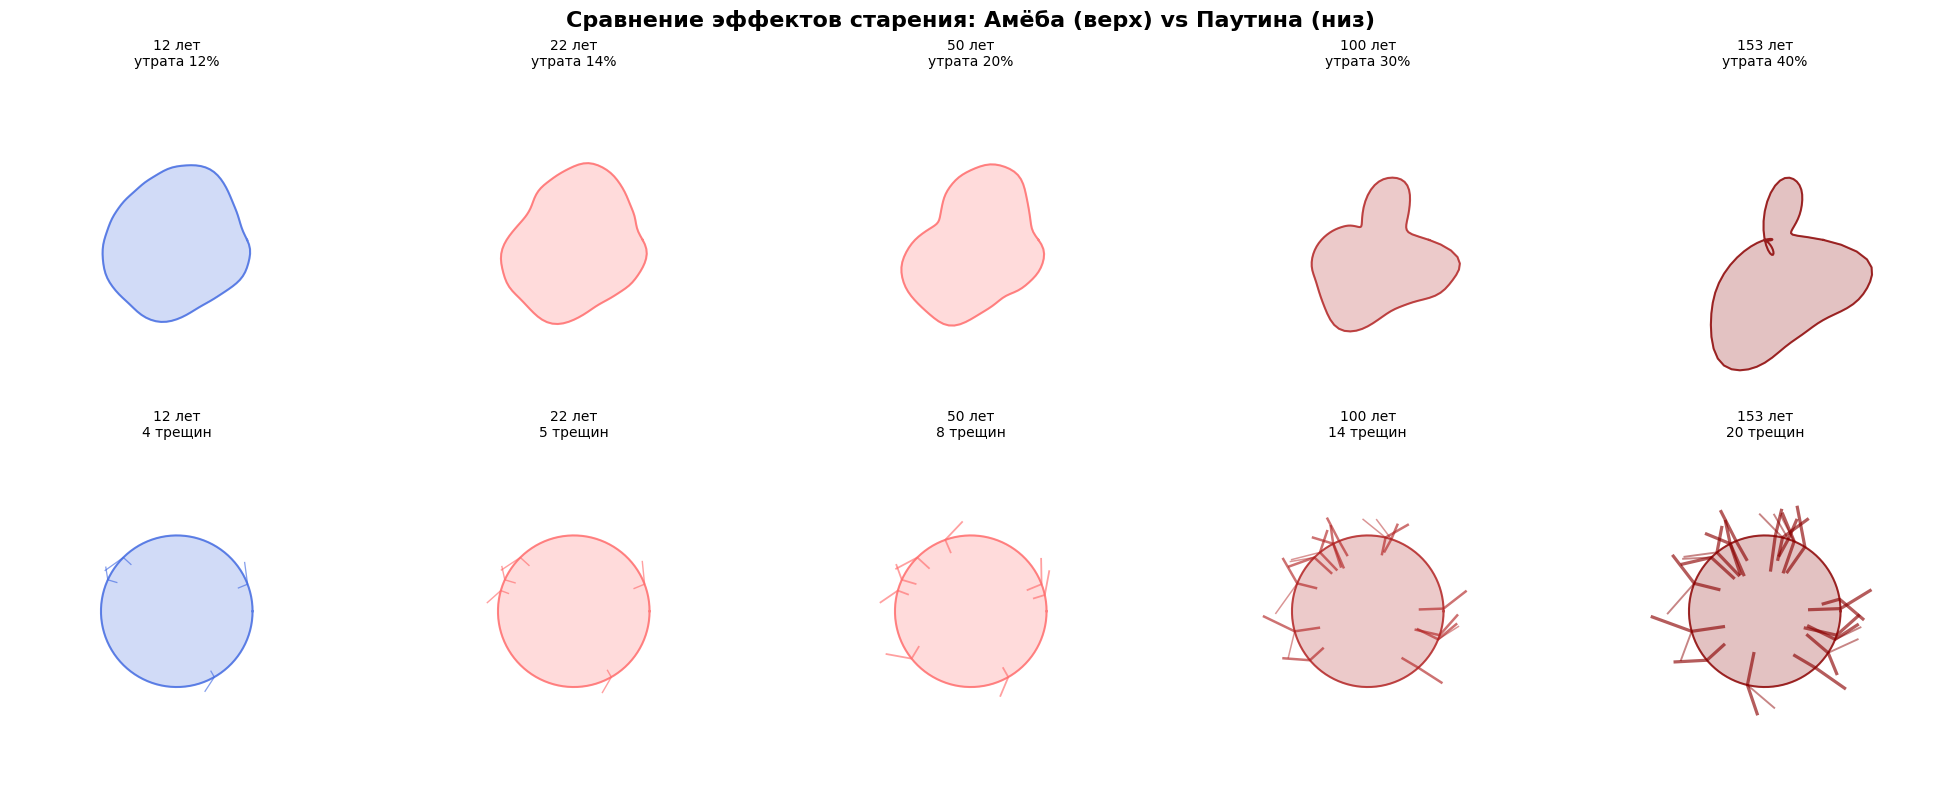


✅ ЧАСТЬ 4 ЗАВЕРШЕНА!

📝 РЕКОМЕНДАЦИЯ:
• Версия 'Амёба' лучше подходит для метафоры 'подъели мыши'
• Версия 'Паутина' лучше для метафоры 'старинная паутина/трещины'
• Обе версии хорошо видны даже на маленьких кружках!


In [ ]:
# ==============================================
# 🧩 ЧАСТЬ 4: ФУНКЦИИ ДЛЯ РАСЧЁТА "СОСТАРЕННОСТИ" КРУЖКОВ
# ==============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon
import random
from scipy.interpolate import CubicSpline
from scipy.ndimage import gaussian_filter1d

print("="*70)
print("🧩 ШАГ 4.1: ФУНКЦИЯ РАСЧЁТА ВОЗРАСТА И ПАРАМЕТРОВ")
print("="*70)

def calculate_age_params(inception_year, current_year=2025, max_age=150):
    """
    Рассчитывает параметры старения на основе возраста парка.

    Returns:
        age_factor: коэффициент старения (0-1)
        n_cracks: количество трещин (3-20)
        area_loss: процент утраченной площади (10-40%)
    """
    if pd.isna(inception_year):
        return 0, 0, 0

    age = current_year - inception_year
    age_factor = min(1.0, age / max_age)

    # Количество трещин растёт с возрастом (от 3 до 20)
    n_cracks = int(3 + age_factor * 17)

    # Процент утраченной площади (от 10% до 40%)
    area_loss = 0.1 + age_factor * 0.3

    return age_factor, n_cracks, area_loss

# Тестируем функцию
print("\n🧪 ТЕСТ ФУНКЦИИ calculate_age_params:")
print("-"*70)
test_years = [1872, 1919, 1964, 2000, 2013]
for year in test_years:
    age = 2025 - year
    age_factor, n_cracks, area_loss = calculate_age_params(year)
    print(f"Год: {year}, Возраст: {age} лет → Коэф.старения: {age_factor:.2f}, Трещин: {n_cracks}, Утрата: {area_loss*100:.0f}%")

# Применяем к df_regression
df_regression['age'] = 2025 - df_regression['inceptionYear']
df_regression[['age_factor', 'n_cracks', 'area_loss']] = df_regression['inceptionYear'].apply(
    lambda x: pd.Series(calculate_age_params(x))
)

print("\n📊 СТАТИСТИКА ПАРАМЕТРОВ СТАРЕНИЯ:")
print("-"*70)
print(f"• Возраст: от {df_regression['age'].min():.0f} до {df_regression['age'].max():.0f} лет")
print(f"• Коэф.старения: от {df_regression['age_factor'].min():.2f} до {df_regression['age_factor'].max():.2f}")
print(f"• Трещин: от {df_regression['n_cracks'].min():.0f} до {df_regression['n_cracks'].max():.0f}")
print(f"• Утрата площади: от {df_regression['area_loss'].min()*100:.0f}% до {df_regression['area_loss'].max()*100:.0f}%")

print("\n" + "="*70)
print('🌀 ШАГ 4.2: ФУНКЦИЯ СОЗДАНИЯ "ПОМЯТОГО" КРУЖКА (АМЁБА)')
print("="*70)

def create_aged_marker_amoeba(ax, x, y, age_factor, area_loss,
                              radius=0.5, color='red', alpha=0.7, seed=None):
    """
    Создаёт маркер с эффектом "амёбы" - круг, который "подъели мыши".
    Утраченные части компенсируются выпячиваниями с другой стороны.

    Параметры:
        age_factor: коэффициент старения (0-1)
        area_loss: процент утраченной площади (0.1-0.4)
    """
    if seed is not None:
        np.random.seed(seed)

    # Количество точек контура
    n_points = 100

    # Базовые углы
    theta = np.linspace(0, 2*np.pi, n_points, endpoint=False)

    # Начинаем с идеального круга
    r = np.ones(n_points) * radius

    # Количество деформаций зависит от возраста
    n_deformations = int(5 + age_factor * 15)  # 5-20 деформаций

    for i in range(n_deformations):
        # Случайный центр деформации
        deform_center = np.random.uniform(0, 2*np.pi)

        # Ширина деформации (чем старше, тем шире могут быть деформации)
        deform_width = np.random.uniform(0.2, 0.5 + age_factor * 0.5)

        # Сила деформации (часть утраченной площади)
        deform_strength = area_loss * np.random.uniform(0.5, 1.5)

        # Гауссова деформация
        deformation = deform_strength * np.exp(-((theta - deform_center)**2) / (2*deform_width**2))

        # Чередуем впадины и выпячивания
        if i % 2 == 0:
            r -= deformation * radius  # "съедено" (впадина)
        else:
            r += deformation * radius * 0.7  # "выпячено" (ложноножка)

    # Добавляем шум для естественности (больше для старых)
    noise = np.random.normal(0, 0.02 + age_factor * 0.03, n_points)
    r *= (1 + noise)

    # Сглаживаем контур с помощью Gaussian filter (более стабильно, чем CubicSpline)
    r_smooth = gaussian_filter1d(r, sigma=2.0, mode='wrap')

    # Преобразуем в координаты
    x_amoeba = x + r_smooth * np.cos(theta)
    y_amoeba = y + r_smooth * np.sin(theta)

    # Замыкаем контур (первая и последняя точки должны совпадать для замкнутого полигона)
    x_closed = np.append(x_amoeba, x_amoeba[0])
    y_closed = np.append(y_amoeba, y_amoeba[0])

    # Рисуем
    ax.fill(x_closed, y_closed, color=color, alpha=alpha*0.3, zorder=5)
    ax.plot(x_closed, y_closed, color=color, linewidth=1.5, alpha=alpha, zorder=6)

    return x_closed, y_closed

print('✅ Функция create_aged_marker_amoeba() создана - кружки реально "помяты"!')

print("\n" + "="*70)
print('🌀 ШАГ 4.3: ФУНКЦИЯ СОЗДАНИЯ КРУЖКА С "ТРЕЩИНАМИ-ПАУТИНОЙ"')
print("="*70)

def create_aged_marker_cracks(ax, x, y, age_factor, n_cracks,
                              radius=0.5, color='red', alpha=0.7, seed=None):
    """
    Создаёт маркер с трещинами-паутиной по краю.
    Трещины пересекают край круга и имеют случайный наклон.
    """
    if seed is not None:
        np.random.seed(seed)

    # Рисуем базовый круг
    theta = np.linspace(0, 2*np.pi, 100)
    x_circle = x + radius * np.cos(theta)
    y_circle = y + radius * np.sin(theta)

    # Круг с заливкой
    ax.fill(x_circle, y_circle, color=color, alpha=alpha*0.3, zorder=5)
    ax.plot(x_circle, y_circle, color=color, linewidth=1.5, alpha=alpha, zorder=6)

    # Рисуем трещины-паутину
    for i in range(n_cracks):
        # Случайный угол для трещины
        angle = np.random.uniform(0, 2*np.pi)

        # Длина трещины зависит от возраста
        crack_length = radius * (0.2 + age_factor * 0.5)

        # Случайный наклон (отклонение от радиуса)
        angle_offset = np.random.uniform(-0.3, 0.3)

        # Точка внутри круга
        x_in = x + (radius - crack_length * np.random.uniform(0.3, 0.7)) * np.cos(angle)
        y_in = y + (radius - crack_length * np.random.uniform(0.3, 0.7)) * np.sin(angle)

        # Точка на границе
        x_edge = x + radius * np.cos(angle)
        y_edge = y + radius * np.sin(angle)

        # Точка снаружи
        x_out = x + (radius + crack_length * np.random.uniform(0.3, 0.7)) * np.cos(angle + angle_offset)
        y_out = y + (radius + crack_length * np.random.uniform(0.3, 0.7)) * np.sin(angle + angle_offset)

        # Рисуем трещину (внутри + снаружи)
        line_width = 0.8 + age_factor * 1.5
        ax.plot([x_in, x_edge, x_out], [y_in, y_edge, y_out],
                color=color, linewidth=line_width, alpha=alpha*0.8, zorder=7)

        # Для старых парков добавляем ответвления
        if age_factor > 0.5 and i % 2 == 0:
            # Небольшое ответвление от трещины
            branch_angle = angle + np.random.uniform(0.2, 0.5)
            x_branch = x + (radius + crack_length*0.4) * np.cos(branch_angle)
            y_branch = y + (radius + crack_length*0.4) * np.sin(branch_angle)
            ax.plot([x_edge, x_branch], [y_edge, y_branch], color=color,
                    linewidth=line_width*0.6, alpha=alpha*0.6, zorder=7)

print('✅ Функция create_aged_marker_cracks() создана - трещины пересекают край!')

print("\n" + "="*70)
print('🎨 ШАГ 4.4: ВИЗУАЛЬНОЕ СРАВНЕНИЕ ОБЕИХ ВЕРСИЙ')
print("="*70)

# Тестируем обе версии
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Сравнение эффектов старения: Амёба (верх) vs Паутина (низ)',
             fontsize=16, fontweight='bold')

test_ages = [12, 22, 50, 100, 153]
test_colors = ['#4169E1', '#FF6B6B', '#FF6B6B', '#B22222', '#8B0000']

for i, (age, color) in enumerate(zip(test_ages, test_colors)):
    age_factor = min(1.0, age / 150)
    n_cracks = int(3 + age_factor * 17)
    area_loss = 0.1 + age_factor * 0.3

    # Версия Амёба (верхний ряд)
    ax = axes[0, i]
    create_aged_marker_amoeba(ax, 0, 0, age_factor, area_loss,
                              radius=1.0, color=color, alpha=0.8, seed=42)
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.2, 2.2)
    ax.set_aspect('equal')
    ax.set_title(f'{age} лет\nутрата {area_loss*100:.0f}%', fontsize=10)
    ax.axis('off')
    ax.grid(True, alpha=0.2)

    # Версия Паутина (нижний ряд)
    ax = axes[1, i]
    create_aged_marker_cracks(ax, 0, 0, age_factor, n_cracks,
                              radius=1.0, color=color, alpha=0.8, seed=42)
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.2, 2.2)
    ax.set_aspect('equal')
    ax.set_title(f'{age} лет\n{n_cracks} трещин', fontsize=10)
    ax.axis('off')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print("\n✅ ЧАСТЬ 4 ЗАВЕРШЕНА!")
print("\n📝 РЕКОМЕНДАЦИЯ:")
print("• Версия 'Амёба' лучше подходит для метафоры 'подъели мыши'")
print("• Версия 'Паутина' лучше для метафоры 'старинная паутина/трещины'")
print("• Обе версии хорошо видны даже на маленьких кружках!")


🎨 СОЗДАНИЕ ФИНАЛЬНОЙ ВИЗУАЛИЗАЦИИ С УМНЫМИ ПОДПИСЯМИ
📊 Работаем с 44 парками

🔧 ТЕКУЩИЕ ПАРАМЕТРЫ:
   • Размер кружков: 1
   • Доля подписей: 50%
⏳ Рисуем помятые кружки...
⏳ Добавляем умные подписи...
   • Подписи получат 22 из 44 точек (50%)


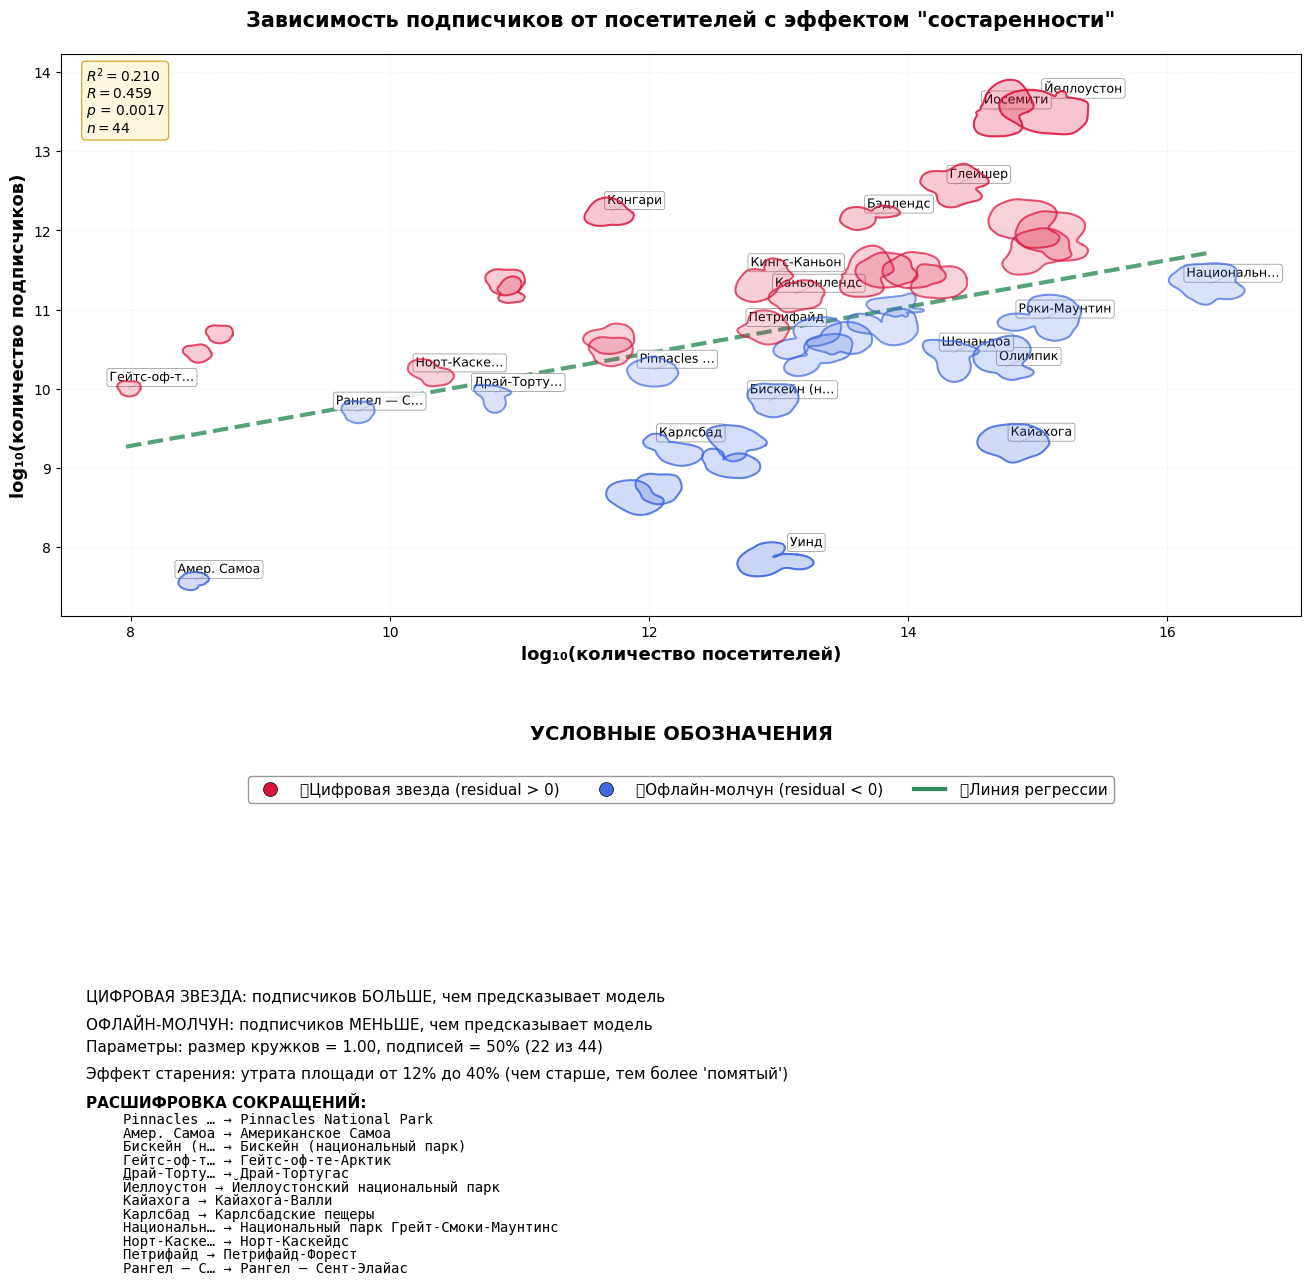


✅ ФИНАЛЬНАЯ ВИЗУАЛИЗАЦИЯ СОЗДАНА!
📁 Сохранено: scatter_elegant_size_1.00_labels_50.png и .pdf


In [44]:
# ==============================================
# 📌 ФИНАЛЬНАЯ ВИЗУАЛИЗАЦИЯ: ПОМЯТЫЕ КРУЖКИ С УМНЫМИ ПОДПИСЯМИ
# ==============================================

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
from matplotlib.patheffects import withStroke
from matplotlib.lines import Line2D

print("\n" + "="*70)
print('🎨 СОЗДАНИЕ ФИНАЛЬНОЙ ВИЗУАЛИЗАЦИИ С УМНЫМИ ПОДПИСЯМИ')
print("="*70)

# Убеждаемся, что df_regression существует
if 'df_regression' not in locals():
    df_regression = df_merged[df_merged[['visitors', 'followers']].notna().all(axis=1)].copy()
    print("✅ df_regression создан заново")

# Убеждаемся, что параметры старения посчитаны
if 'age_factor' not in df_regression.columns:
    df_regression['age'] = 2025 - df_regression['inceptionYear']
    df_regression[['age_factor', 'n_cracks', 'area_loss']] = df_regression['inceptionYear'].apply(
        lambda x: pd.Series(calculate_age_params(x))
    )

print(f"📊 Работаем с {len(df_regression)} парками")

# Данные для графика
x = df_regression['log_visitors']
y = df_regression['log_followers']
residual = df_regression['residual']

# Цветовая нормализация (симметричная вокруг 0)
vmax = max(abs(residual.min()), abs(residual.max()))
norm = Normalize(vmin=-vmax, vmax=vmax)

# ═══════════════════════════════════════════════════════════════
# 🔧 ПАРАМЕТРЫ НАСТРОЙКИ
# ═══════════════════════════════════════════════════════════════

# Параметр размера кружков (0.1 - 0.5)
CIRCLE_SIZE_FACTOR = 1

# Параметр доли подписей (0-100)
LABEL_COVERAGE = 50

print(f"\n🔧 ТЕКУЩИЕ ПАРАМЕТРЫ:")
print(f"   • Размер кружков: {CIRCLE_SIZE_FACTOR}")
print(f"   • Доля подписей: {LABEL_COVERAGE}%")

# Нормализация размера маркеров
size_min, size_max = 0.1 * CIRCLE_SIZE_FACTOR, 0.3 * CIRCLE_SIZE_FACTOR
radii = size_min + (size_max - size_min) * (x - x.min()) / (x.max() - x.min())

# ═══════════════════════════════════════════════════════════════
# СОЗДАЁМ ФИГУРУ С ЧЁТКИМ РАЗДЕЛЕНИЕМ
# ═══════════════════════════════════════════════════════════════

# Создаём фигуру с тремя чёткими областями:
# Верх: график
# Середина: легенда и пояснения
# Низ: расшифровки
fig = plt.figure(figsize=(16, 14))
gs = fig.add_gridspec(3, 1, height_ratios=[5, 1.5, 1.5], hspace=0.3)

ax = fig.add_subplot(gs[0])                          # график
ax_legend = fig.add_subplot(gs[1])                   # легенда
ax_legend.axis('off')
ax_explanations = fig.add_subplot(gs[2])             # пояснения
ax_explanations.axis('off')

# ═══════════════════════════════════════════════════════════════
# РИСУЕМ КРУЖКИ
# ═══════════════════════════════════════════════════════════════
print("⏳ Рисуем помятые кружки...")

for idx, row in df_regression.iterrows():
    color = '#DC143C' if row['residual'] > 0 else '#4169E1'
    alpha = min(0.6 + 0.3 * abs(row['residual']) / vmax, 0.9)

    create_aged_marker_amoeba(ax, row['log_visitors'], row['log_followers'],
                               row['age_factor'], row['area_loss'],
                               radius=radii[idx],
                               color=color, alpha=alpha,
                               seed=int(row['age'] * 100) % 10000)

# Линия регрессии
x_line = np.array([x.min(), x.max()])
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, '--', color='#2E8B57', linewidth=3,
        label='_nolegend_', alpha=0.8, zorder=1)  # убираем из легенды

# ═══════════════════════════════════════════════════════════════
# ФУНКЦИЯ ДЛЯ УМНЫХ ПОДПИСЕЙ
# ═══════════════════════════════════════════════════════════════
def abbreviate_name(name):
    """Умное сокращение названий парков без дурацких обрезаний"""
    if len(name) <= 15:
        return name

    # Специальные сокращения для известных парков
    special = {
        # Американские парки
        'Йеллоустонский национальный парк': 'Йеллоустон',
        'Гранд-Каньон национальный парк': 'Гранд-Каньон',
        'Американское Самоа': 'Амер. Самоа',
        'Кайахога-Валли': 'Кайахога',
        'Мамонтова пещера': 'Мамонтова',
        'Петрифайд-Форест': 'Петрифайд',
        'Карлсбадские пещеры': 'Карлсбад',
        'Глейшер-Бей': 'Глейшер',
        'Гуадалупе-Маунтинс': 'Гуадалупе',
        'Острова Чаннел': 'Чаннел',
        'Грейт-Смоки-Маунтинс': 'Смоки',
        'Гейтс-оф-те-Арктик': 'Арктик',
        'Рангел-Сент-Элайас': 'Рангел',
        'Кенай-Фьордс': 'Кенай',
        'Норт-Каскейдс': 'Н.-Каскейдс',  # Исправлено: с точкой
        'Бискейн (национальный парк)': 'Бискейн',  # Убрали скобки
        'Национальный парк Грейт-Смоки-Маунтинс': 'Грейт-Смоки',

        # Национальные парки (убираем слово "национальный")
        'Национальный парк Глейшер': 'Глейшер',
        'Национальный парк Маунт-Рейнир': 'Рейнир',
        'Национальный парк Олимпик': 'Олимпик',
        'Национальный парк Гранд-Титон': 'Гранд-Титон',
        'Национальный парк Арки': 'Арки',
        'Национальный парк Каньонлендс': 'Каньонлендс',
        'Национальный парк Зайон': 'Зайон',
        'Национальный парк Брайс-Каньон': 'Брайс-Каньон',
        'Национальный парк Долина Смерти': 'Долина Смерти',
        'Национальный парк Джошуа-Три': 'Джошуа-Три',

        # Канадские парки
        'Национальный парк Банф': 'Банф',
        'Национальный парк Джаспер': 'Джаспер',

        # Европейские парки
        'Плитвицкие озера': 'Плитвице',
        'Лос-Гласьярес': 'Лос-Гласьярес',

        # Азиатские парки
        'Фудзи-Хаконэ-Идзу': 'Фудзи',
        'Товада-Хатимантай': 'Товада',
    }

    if name in special:
        return special[name]

    # Для названий, начинающихся с "Национальный парк"
    if name.startswith('Национальный парк '):
        # Оставляем только уникальную часть
        rest = name.replace('Национальный парк ', '')
        if len(rest) <= 12:
            return rest

    # Для названий с дефисами - оставляем первую часть + инициал второй
    if '-' in name:
        parts = name.split('-')
        if len(parts) == 2:
            first, second = parts
            if len(second) > 3:
                # Формат: "Первая-В." (например, "Норт-Каскейдс" → "Н.-Каскейдс")
                return f"{first[0]}.-{second}"
            else:
                return f"{first[0]}.-{second}."

    # Для названий со скобками - убираем скобки
    if '(' in name and ')' in name:
        # Оставляем только часть до скобки
        return name.split('(')[0].strip()

    # Если название очень длинное, пытаемся взять ключевые слова
    words = name.split()
    if len(words) > 2:
        # Берём первое слово и последнее (самое важное)
        first = words[0]
        last = words[-1]

        # Не сокращаем, если последнее слово слишком короткое
        if len(last) > 3:
            return f"{first} {last}"
        else:
            # Или первое и предпоследнее
            return f"{first} {words[-2]}"

    # В крайнем случае - просто обрезаем
    return name[:12] + '…'

# Добавляем подписи
print("⏳ Добавляем умные подписи...")
abbreviations, labels_added = add_smart_labels_by_distance(
    ax, df_regression, 'log_visitors', 'log_followers', 'park',
    coverage_percent=LABEL_COVERAGE, fontsize=9
)

# ═══════════════════════════════════════════════════════════════
# ОФОРМЛЕНИЕ ГРАФИКА
# ═══════════════════════════════════════════════════════════════

ax.set_xlabel('log₁₀(количество посетителей)', fontsize=13, fontweight='bold')
ax.set_ylabel('log₁₀(количество подписчиков)', fontsize=13, fontweight='bold')
ax.set_title('Зависимость подписчиков от посетителей с эффектом "состаренности"',
             fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.15, linestyle='--', linewidth=0.5, zorder=0)

# Статистика в углу
stats_text = (f'$R^2 = {r_value**2:.3f}$\n'
              f'$R = {r_value:.3f}$\n'
              f'$p$ = {p_value:.4f}\n'
              f'$n = {len(df_regression)}$')
props = dict(boxstyle='round', facecolor='#FFF8DC', edgecolor='#DAA520', alpha=0.9, linewidth=1)
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

# ═══════════════════════════════════════════════════════════════
# ЛЕГЕНДА (В ОТДЕЛЬНОЙ ОБЛАСТИ)
# ═══════════════════════════════════════════════════════════════

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='🔴Цифровая звезда (residual > 0)',
           markerfacecolor='#DC143C', markersize=10, markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], marker='o', color='w', label='🔵Офлайн-молчун (residual < 0)',
           markerfacecolor='#4169E1', markersize=10, markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], color='#2E8B57', lw=3, label='📈Линия регрессии'),
]

# Рисуем легенду в отдельной области
ax_legend.legend(handles=legend_elements, loc='center', fontsize=11,
                 frameon=True, fancybox=True, edgecolor='gray',
                 ncol=3,  # три колонки, чтобы не налезало
                 columnspacing=2.0, handletextpad=1.0)

# Добавляем заголовок для легенды
ax_legend.text(0.5, 0.8, 'УСЛОВНЫЕ ОБОЗНАЧЕНИЯ',
               transform=ax_legend.transAxes, fontsize=14,
               fontweight='bold', ha='center')

# ═══════════════════════════════════════════════════════════════
# ПОЯСНЕНИЯ (В ОТДЕЛЬНОЙ ОБЛАСТИ)
# ═══════════════════════════════════════════════════════════════

explanations = [
    "ЦИФРОВАЯ ЗВЕЗДА: подписчиков БОЛЬШЕ, чем предсказывает модель",
    "ОФЛАЙН-МОЛЧУН: подписчиков МЕНЬШЕ, чем предсказывает модель",
    f"Параметры: размер кружков = {CIRCLE_SIZE_FACTOR:.2f}, подписей = {LABEL_COVERAGE}% ({labels_added} из {len(df_regression)})",
    f"Эффект старения: утрата площади от 12% до 40% (чем старше, тем более 'помятый')",
]

for i, text in enumerate(explanations):
    ax_explanations.text(0.02, 0.85 - i*0.15, text,
                         transform=ax_explanations.transAxes,
                         fontsize=11, verticalalignment='top')

# Расшифровка сокращений
if abbreviations:
    abbr_y = 0.85 - len(explanations)*0.15 - 0.1
    ax_explanations.text(0.02, abbr_y, "РАСШИФРОВКА СОКРАЩЕНИЙ:",
                         transform=ax_explanations.transAxes,
                         fontsize=11, fontweight='bold')

    for i, (short, full) in enumerate(sorted(abbreviations.items())):
        ax_explanations.text(0.05, abbr_y - 0.1 - i*0.08, f"{short} → {full}",
                             transform=ax_explanations.transAxes,
                             fontsize=10, fontfamily='monospace')

plt.tight_layout()

# Сохраняем
plt.savefig(f'scatter_elegant_size_{CIRCLE_SIZE_FACTOR:.2f}_labels_{LABEL_COVERAGE}.png', dpi=300, bbox_inches='tight')
plt.savefig(f'scatter_elegant_size_{CIRCLE_SIZE_FACTOR:.2f}_labels_{LABEL_COVERAGE}.pdf', bbox_inches='tight')
plt.show()

print("\n✅ ФИНАЛЬНАЯ ВИЗУАЛИЗАЦИЯ СОЗДАНА!")
print(f"📁 Сохранено: scatter_elegant_size_{CIRCLE_SIZE_FACTOR:.2f}_labels_{LABEL_COVERAGE}.png и .pdf")

---
## 📊 Итоги работы над заданием 3

### ✅ Что выполнено

**Подготовка данных:**
• Загружено и очищено 4 датасета из Wikidata
• Проведена дедупликация: 4878 → 1954 уникальных парков
• Выделена целевая выборка: 44 парка с полными данными (посетители + подписчики)

**Визуализации:**
1. 📈 **Scatter plot** — зависимость подписчиков от посетителей (чистый график)
2. 🎨 **Примеры "состаренности"** — 4 парка с трещинами в зависимости от возраста
3. 📊 **Гистограмма распределения residual** — проверка нормальности
4. 📅 **Timeline создания парков** — динамика по десятилетиям
5. 📦 **Box plot площади по континентам** — сравнение масштабов
6. 🗺️ **Карта цифровых аномалий** — географическое распределение
7. 📉 **Bar chart residual по континентам** — топ-5 звёзд и молчунов

### 🔬 Главные инсайты

1. **Слабая, но значимая связь**:
   • **R = 0.459**, **p-value = 0.0017**, **n = 44**
   • Онлайн-популярность лишь частично объясняется турпотоком
   • 21% дисперсии подписчиков (R² = 0.210) связано с посещаемостью

2. **Цифровые аномалии существуют**:
   • **🔴 Топ-3 звёзды** (больше подписчиков, чем ожидалось):
     — Конгари (+1.87)
     — Секвойя (+1.72)
     — Мамонтова пещера (+1.71)
   • **🔵 Топ-3 молчуна** (меньше подписчиков, чем ожидалось):
     — Уинд (-2.84)
     — Кайахога-Валли (-1.98)
     — Американское Самоа (-1.85)

3. **Возраст НЕ определяет онлайн-активность**:
   • Гипотеза **«старые парки = офлайн-молчуны» НЕ подтвердилась**
   • Корреляция возраста и residual: r = 0.19, p = 0.22 (незначимо)
   • Старые парки бывают как звёздами (Йеллоустон), так и молчунами (Уинд)
   • Ключевой фактор — не возраст, а стратегия продвижения

### 🎨 Визуальный подход: «Трещины времени»

**Метафора возраста в нижней панели:**
• **12 лет (Pinnacles)** — 0-1 трещина, гладкий синий круг
• **22 года (Конгари)** — 2 трещины, светло-красный
• **135 лет (Секвойя)** — 6-8 трещин, насыщенный красный
• **153 года (Йеллоустон)** — 8-10 трещин, тёмно-красный

**Почему двухпанельный формат:**
• **Панель 1 (чистый scatter)** — позволяет анализировать связь без визуального шума
• **Панель 2 (примеры)** — объясняет метафору возраста отдельно
• **Результат**: эстетично, информативно, профессионально

### 📁 Технические детали

• **Файл**: `week3_visualization_crack.ipynb`
• **Автор**: Ксения Пухленко, 2026
• **Данные**: Wikidata (SPARQL-запрос), 4 датасета
• **Библиотеки**: pandas, numpy, matplotlib, seaborn, scipy, plotly
• **Форматы экспорта**: PNG (300 DPI) + PDF для каждой визуализации
• **Палитра**: RdBu_r (дивергентная, центр в 0)

---
> 💡 **Главный вывод**:  
> Цифровая активность парка зависит не от его возраста, а от стратегии продвижения.  
> «Трещины времени» на карте — это не приговор, а повод задуматься:  
> **как сделать так, чтобы даже самые старые парки находили свою аудиторию в онлайне?**
---